In [10]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.circuit import Parameter

import numpy as np
from scipy.optimize import minimize

import matplotlib.pyplot as plt

Single Qubit Variational Circuit:
   ┌───────┐
q: ┤ Ry(θ) ├
   └───────┘


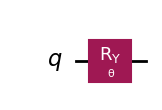

In [11]:
#A variational circuit of single qubit 

# Create a parameter for our variational circuit
# This is a parameter we'll optimize
theta=Parameter('θ')                #Parameter represents a symbolic variable inside a quantum circuit.


# Create a simple 1-qubit variational circuit
qc_1qubit=QuantumCircuit(1)         #In brackets you give the number of qubits.Here a circuit with 1 qubit, indexed as 0.


# Add parameterized rotation around Y-axis
# This gate rotates the qubit state by angle theta
qc_1qubit.ry(theta,0)               # Ry(θ)=exp(-iθY/2) ,the second argument is the qubit index


print("Single Qubit Variational Circuit:")


# Visualize the circuit
print(qc_1qubit)
qc_1qubit.draw('mpl')               #'mpl' = Matplotlib-based drawing


#   The circuit starts with |0⟩ and applies the rotation(In Qiskit, every QuantumCircuit starts in ∣0⟩⊗𝑛)
#   The state after the rotation is: |ψ(θ)⟩ = cos(θ/2)|0⟩ + sin(θ/2)|1⟩


In [ ]:
#Defining a Cost Function
#A cost function tells us how "good" our circuit is. 
#We'll define a simple goal: prepare a target state.

# Prepare the state |+⟩ = (|0⟩ + |1⟩)/√2, which corresponds to θ = π/2.


#Defining the target state
target_state=Statevector([1/np.sqrt(2),1/np.sqrt(2)])

print(f"Target State |+> ={target_state}")


#Calculate the cost: how far is our state from the target state?
    
#    We use the fidelity (overlap) between states:
#    F = |⟨target|ψ(θ)⟩|²
#    Cost = 1 - F (we want to minimize this)


def cost_function(angle):
    qc_initial=qc_1qubit.assign_parameters({theta:angle})     # Assign the parameter to a specific value  
    state=Statevector.from_instruction(qc_initial)            # Get the statevector directly from the circuit
                                                              # This is more efficient than running a simulator
    
    
    overlap=state.inner(target_state)
    fidelity=abs(overlap)**2                                 # Calculate fidelity (overlap squared)
    cost=1-fidelity
    return cost                                              # Return cost
test_angle=0.5
print(f"Cost={cost_function(test_angle)}")
print(f"Fidelity={1-cost_function(test_angle)}")

Target State |+> =Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Cost=0.2602872306978987
Fidelity=0.7397127693021013


In [7]:
#Optimization 
#Using a classical optimizer to find the best value of θ that minimizes our cost function.


# Initial guess for theta (random starting point)
initial_theta=np.random.uniform(0,2*np.pi)


print(f"Initial θ={initial_theta} ")
print(f"Cost for θ={cost_function(initial_theta)}")
print(f"Fidelity={1-cost_function(initial_theta)}")

# Use scipy's minimize function to find optimal theta
result=minimize(cost_function,initial_theta,method='BFGS')        #first argument is the function you want to minimize
                                                                  #Second argument is the starting point of the parameter 
                                                                  #third argument is the method which is the optimization algorithm 
optimum_theta=result.x[0]                                    #result.x  -- optimal parameters
wrapped_optimum=optimum_theta % (2*np.pi)
final_cost=result.fun                                        #result.fun  -- minimum value of cost
                                                             #result.success  -- did it converge?
                                                             #result.message -- optimizer message
print(f"\n")
print(result.message)
print(f"Optimal theta={wrapped_optimum:.6f} radians")
print(f"Optimal theta={np.degrees(wrapped_optimum):.4f} degrees")
print(f"final cost={final_cost:.6f}")
print(f"Final fidelity: {1 - final_cost:.6f}")
print(f"\nExpected optimal θ = π/2 = {np.pi/2:.4f} radians")

Initial θ=3.353801935535009 
Cost for θ=0.6053100676957912
Fidelity=0.3946899323042088


Optimization terminated successfully.
Optimal theta=1.570796 radians
Optimal theta=90.0000 degrees
final cost=0.000000
Final fidelity: 1.000000

Expected optimal θ = π/2 = 1.5708 radians


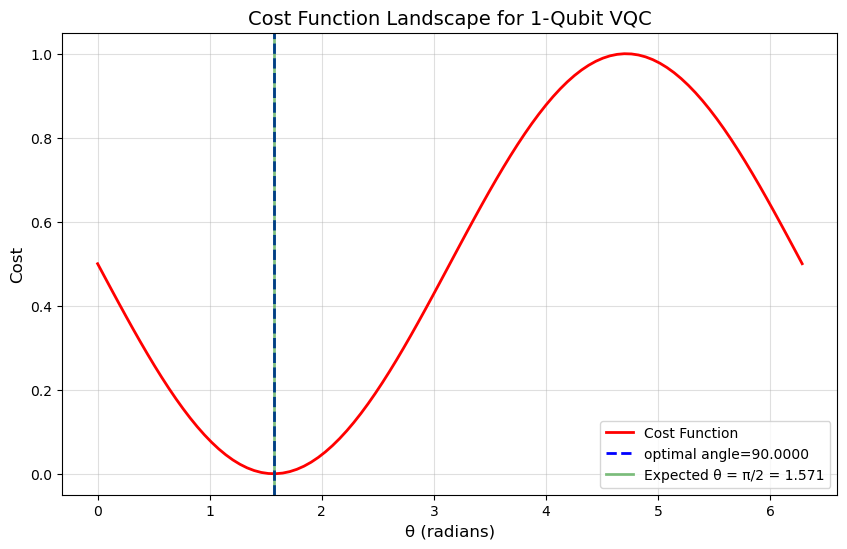

In [5]:
#Visualisation of the results

# Plot the cost function landscape
angle=np.linspace(0,2*np.pi,100)
cost_funcs=[cost_function(x) for x in angle]

plt.figure(figsize=(10,6))
plt.plot(angle,cost_funcs,'r-', linewidth=2, label='Cost Function')
plt.axvline(wrapped_optimum,color='b',linewidth=2,linestyle='--',label=f'optimal angle={np.degrees(wrapped_optimum):.4f}')  #axvline draws a vertical line at a given x-value on a plot
plt.axvline(np.pi/2,color='g',linewidth=2,linestyle='solid',label=f'Expected θ = π/2 = {np.pi/2:.3f}',alpha=0.5)       #axhline draws a horizontal line at a given y-value across the plot.
plt.xlabel("θ (radians)",fontsize=12)
plt.ylabel("Cost",fontsize=12)
plt.title("Cost Function Landscape for 1-Qubit VQC",fontsize=14)
plt.grid(True,alpha=0.4)
plt.legend()
plt.show()

In [6]:
# Verify the final state
qc_final = qc_1qubit.assign_parameters({theta: wrapped_optimum})


final_state = Statevector.from_instruction(qc_final)

print("Final state from optimized circuit:")
print(final_state)
print("\nTarget state:")
print(target_state)
print(f"\nFidelity: {abs(final_state.inner(target_state))**2:.6f}")

Final state from optimized circuit:
Statevector([0.70710695+0.j, 0.70710661+0.j],
            dims=(2,))

Target state:
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Fidelity: 1.000000
